<a href="https://colab.research.google.com/github/BTrifonov/BTrifonov/blob/main/snn_network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install required packages

In [1]:
!pip install snntorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.6/125.6 kB 2.8 MB/s eta 0:00:00


In [14]:
# imports
import snntorch as snn
from snntorch import spikeplot as splt
from snntorch import spikegen

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

import numpy as np

# Reproducibility
torch.manual_seed(0)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [10]:
#@title Plotting Settings
def plot_cur_mem_spk(cur, mem, spk, thr_line=False, vline=False, title=False, ylim_max1=1.25, ylim_max2=1.25):
  # Generate Plots
  fig, ax = plt.subplots(3, figsize=(8,6), sharex=True,
                        gridspec_kw = {'height_ratios': [1, 1, 0.4]})

  # Plot input current
  ax[0].plot(cur, c="tab:orange")
  ax[0].set_ylim([0, ylim_max1])
  ax[0].set_xlim([0, 200])
  ax[0].set_ylabel("Input Current ($I_{in}$)")
  if title:
    ax[0].set_title(title)

  # Plot membrane potential
  ax[1].plot(mem)
  ax[1].set_ylim([0, ylim_max2])
  ax[1].set_ylabel("Membrane Potential ($U_{mem}$)")
  if thr_line:
    ax[1].axhline(y=thr_line, alpha=0.25, linestyle="dashed", c="black", linewidth=2)
  plt.xlabel("Time step")

  # Plot output spike using spikeplot
  splt.raster(spk, ax[2], s=400, c="black", marker="|")
  if vline:
    ax[2].axvline(x=vline, ymin=0, ymax=6.75, alpha = 0.15, linestyle="dashed", c="black", linewidth=2, zorder=0, clip_on=False)
  plt.ylabel("Output spikes")
  plt.yticks([])

  plt.show()

def plot_snn_spikes(spk_in, spk1_rec, spk2_rec, title):
  # Generate Plots
  fig, ax = plt.subplots(3, figsize=(8,7), sharex=True,
                        gridspec_kw = {'height_ratios': [1, 1, 0.4]})

  # Plot input spikes
  splt.raster(spk_in[:,0], ax[0], s=0.03, c="black")
  ax[0].set_ylabel("Input Spikes")
  ax[0].set_title(title)

  # Plot hidden layer spikes
  splt.raster(spk1_rec.reshape(num_steps, -1), ax[1], s = 0.05, c="black")
  ax[1].set_ylabel("Hidden Layer")

  # Plot output spikes
  splt.raster(spk2_rec.reshape(num_steps, -1), ax[2], c="black", marker="|")
  ax[2].set_ylabel("Output Spikes")
  ax[2].set_ylim([0, 10])

  plt.show()


def plot_single_neuron(current, spk_rec, mem_rec, title="Single LIF neuron"):
    T = len(current)
    t_axis = torch.arange(T)

    fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)

    # Input current
    axes[0].plot(t_axis, current.numpy())
    axes[0].set_ylabel("Input current")
    axes[0].set_title(title)

    # Membrane potential
    axes[1].plot(t_axis, mem_rec.numpy())
    axes[1].set_ylabel("Membrane")

    # Spikes
    spike_times = t_axis[spk_rec > 0]
    axes[2].scatter(spike_times.numpy(), torch.ones_like(spike_times).numpy(), marker="|", s=200)
    axes[2].set_ylabel("Spikes")
    axes[2].set_xlabel("Time step")
    axes[2].set_ylim(0.8, 1.2)

    plt.tight_layout()
    plt.show()

def plot_two_stream_test(basal, apical, total, spk_rec, mem_rec, title="Basal / Apical Test"):
    T = len(basal)
    t_axis = torch.arange(T)

    fig, axes = plt.subplots(5, 1, figsize=(10, 8), sharex=True)

    axes[0].plot(t_axis, basal.numpy())
    axes[0].set_ylabel("Basal")
    axes[0].set_title(title)

    axes[1].plot(t_axis, apical.numpy())
    axes[1].set_ylabel("Apical")

    axes[2].plot(t_axis, total.numpy())
    axes[2].set_ylabel("Total")

    axes[3].plot(t_axis, mem_rec.numpy())
    axes[3].set_ylabel("Mem")

    spike_times = t_axis[spk_rec > 0]
    axes[4].scatter(spike_times.numpy(), torch.ones_like(spike_times).numpy(), marker="|", s=200)
    axes[4].set_ylabel("Spikes")
    axes[4].set_xlabel("Time step")
    axes[4].set_ylim(0.8, 1.2)

    plt.tight_layout()
    plt.show()

# LIF Neuron Setup

## Neuron Definitions

In [11]:
def run_single_lif(
    input_current,
    beta=0.9,
    threshold=1.0,
    reset_mechanism="zero",
):
    """
    Run a single built-in snnTorch LIF neuron over a 1D current sequence.

    Parameters
    ----------
    input_current : torch.Tensor of shape [T]
        Current injected at each timestep.
    beta : float
        Membrane decay factor.
    threshold : float
        Spiking threshold.
    reset_mechanism : str
        "zero" or "subtract".

    Returns
    -------
    spk_rec : torch.Tensor [T]
        Spike output over time.
    mem_rec : torch.Tensor [T]
        Membrane potential over time.
    """
    lif = snn.Leaky(beta=beta, threshold=threshold, reset_mechanism=reset_mechanism).to(device)

    mem = None
    spk_rec = []
    mem_rec = []

    # Iterate through time exactly as you will later do in the network
    for t in range(input_current.shape[0]):
        cur_t = input_current[t].view(1).to(device)  # shape [1]
        spk, mem = lif(cur_t, mem)

        spk_rec.append(spk.detach().cpu())
        mem_rec.append(mem.detach().cpu())

    spk_rec = torch.stack(spk_rec).squeeze(-1)
    mem_rec = torch.stack(mem_rec).squeeze(-1)

    return spk_rec, mem_rec


def run_single_lif_two_streams(
    basal_current,
    apical_current,
    g_apical=1.0,
    beta=0.9,
    threshold=1.0,
    reset_mechanism="zero",
):
    """
    Run a single snnTorch LIF neuron with two current streams:
    - basal current: feedforward / prediction
    - apical current: teaching / modulation

    Total current is:
        I_total = I_basal + g_apical * I_apical

    Parameters
    ----------
    basal_current : torch.Tensor [T]
    apical_current : torch.Tensor [T]
    g_apical : float
        Gain applied to the apical current.
    beta : float
        Membrane decay factor.
    threshold : float
        Spiking threshold.
    reset_mechanism : str
        "zero" or "subtract"

    Returns
    -------
    total_current : torch.Tensor [T]
    spk_rec : torch.Tensor [T]
    mem_rec : torch.Tensor [T]
    """
    assert basal_current.shape == apical_current.shape, "Basal and apical currents must have same shape."

    lif = snn.Leaky(
        beta=beta,
        threshold=threshold,
        reset_mechanism=reset_mechanism
    ).to(device)

    mem = None
    spk_rec = []
    mem_rec = []

    total_current = basal_current + g_apical * apical_current

    for t in range(total_current.shape[0]):
        cur_t = total_current[t].view(1).to(device)
        spk, mem = lif(cur_t, mem)

        spk_rec.append(spk.detach().cpu())
        mem_rec.append(mem.detach().cpu())

    spk_rec = torch.stack(spk_rec).squeeze(-1)
    mem_rec = torch.stack(mem_rec).squeeze(-1)

    return total_current, spk_rec, mem_rec

## Neuron Tests

**Neuron with single current input**


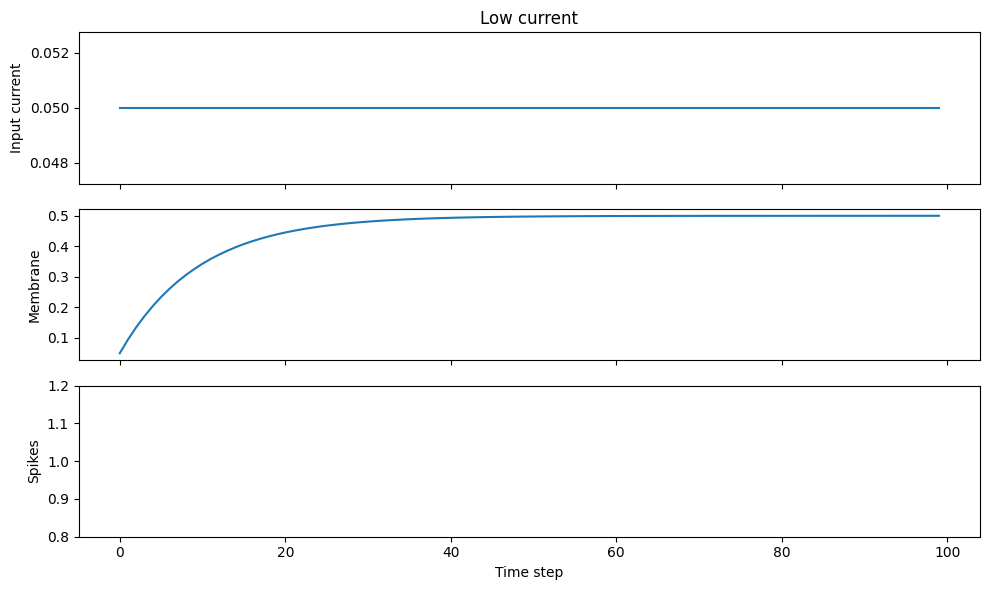

Low current | firing rate = 0.000


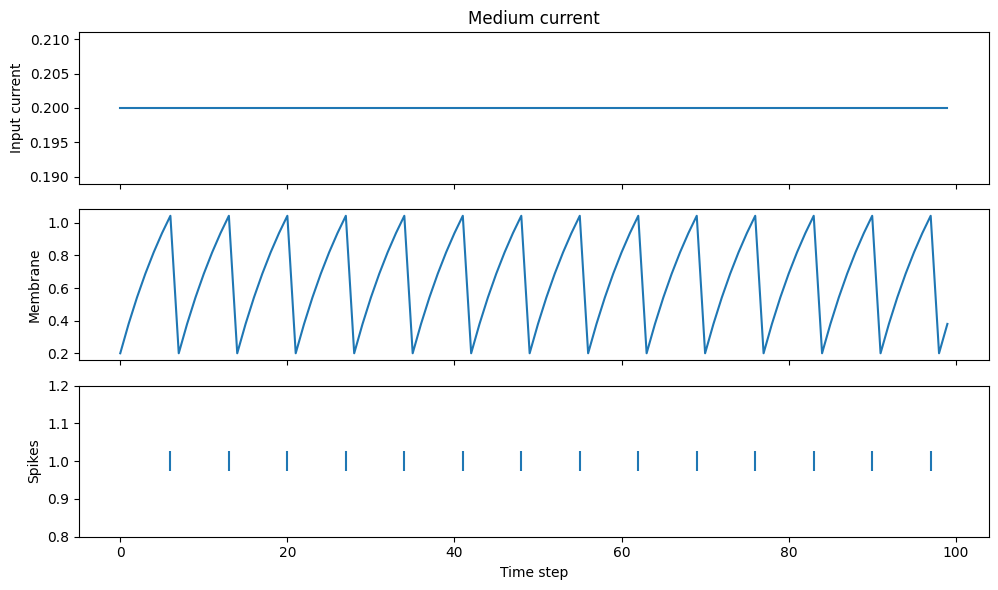

Medium current | firing rate = 0.140


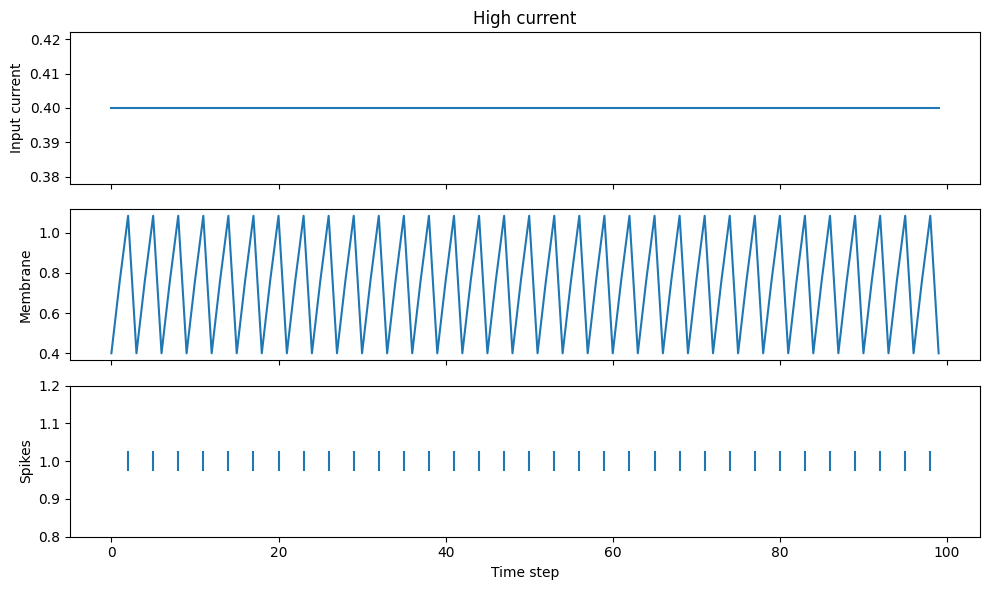

High current | firing rate = 0.330


In [12]:
# This is the actual "configuration sanity check":
# we are not testing whether snnTorch works,
# we are testing whether our chosen parameters lead to useful behavior.

T = 100
beta = 0.9
threshold = 1.0

currents = {
    "Low current": torch.ones(T) * 0.05,
    "Medium current": torch.ones(T) * 0.20,
    "High current": torch.ones(T) * 0.40,
}

for name, current in currents.items():
    spk_rec, mem_rec = run_single_lif(
        current,
        beta=beta,
        threshold=threshold,
        reset_mechanism="zero",
    )
    plot_single_neuron(current, spk_rec, mem_rec, title=name)

    firing_rate = spk_rec.float().mean().item()
    print(f"{name} | firing rate = {firing_rate:.3f}")

**Neuron with basal and apical current input**

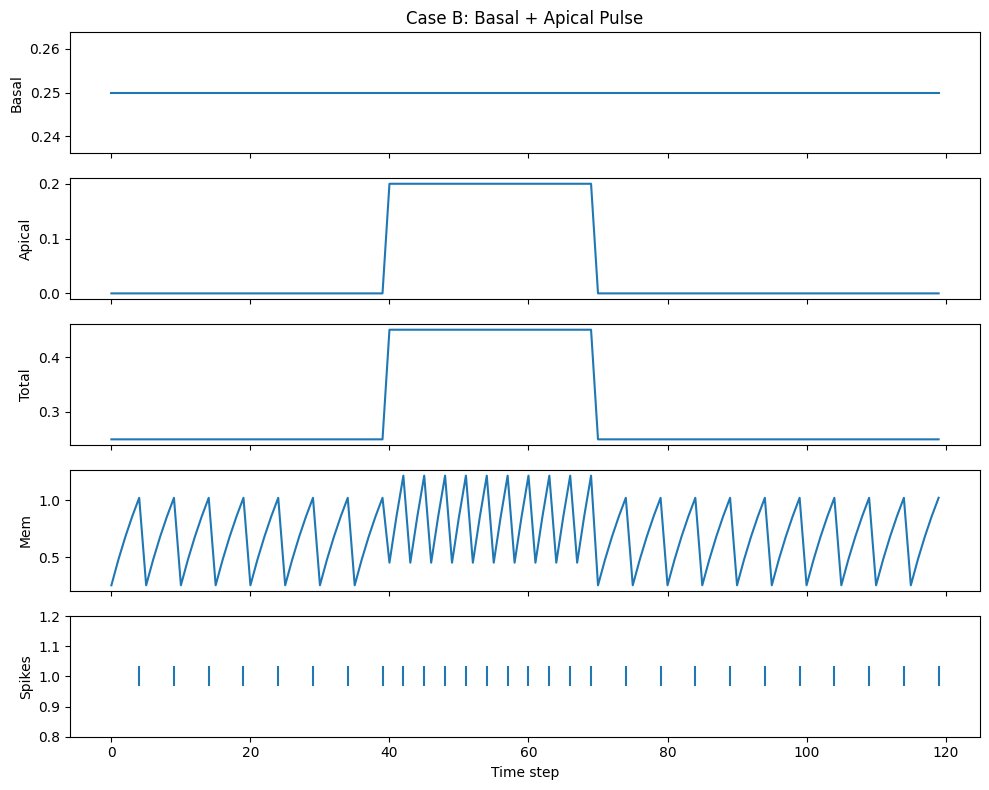

Firing rate (basal + apical pulse): 0.23333333432674408


In [13]:
# Now add an apical pulse on top of the same basal current.
# This is the key test: can an extra teaching/modulation current
# shift the neuron's behavior in a predictable way?

T = 120
basal_current = torch.ones(T) * 0.25
apical_current = torch.zeros(T)

# Add a pulse in the middle
apical_current[40:70] = 0.20

total, spk_rec, mem_rec = run_single_lif_two_streams(
    basal_current=basal_current,
    apical_current=apical_current,
    g_apical=1.0,
    beta=beta,
    threshold=threshold,
)

plot_two_stream_test(
    basal_current,
    apical_current,
    total,
    spk_rec,
    mem_rec,
    title="Case B: Basal + Apical Pulse"
)

print("Firing rate (basal + apical pulse):", spk_rec.float().mean().item())

# Spike Data Generation

In [34]:
def generate_random_spikes(
    n_samples: int,
    num_steps: int,
    n_inputs: int,
    max_rate: float = 1.0,
    seed: int = 0,
):
    """
    Generate random spike-train samples using Poisson/Bernoulli rate encoding.

    Random firing probabilities in [0, max_rate] are generated and converted
    into spikes using snnTorch's `spikegen.rate_conv`. Each sample has shape
    [time_steps, batch_size, input_neurons].

    Parameters
    ----------
    n_samples : int
        Number of spike-train samples to generate.
    num_steps : int
        Number of simulation time steps.
    n_inputs : int
        Number of input neurons.
    max_rate : float, optional
        Maximum firing probability per timestep (default = 1.0).
    seed : int, optional
        Random seed for reproducibility.

    Returns
    -------
    torch.Tensor
        Tensor of shape [n_samples, num_steps, 1, n_inputs].
    """

    torch.manual_seed(seed)
    spikes = []

    for _ in range(n_samples):
        spike_prob = torch.rand(num_steps, n_inputs) * max_rate
        spk = spikegen.rate_conv(spike_prob).unsqueeze(1)  # [T, 1, N]
        spikes.append(spk)

    return torch.stack(spikes)

# Network

## Forward Simulation of an Untrained Spiking Feedforward Network

We need to construct 2-layer autoencoder with a hiddent latent layer of 16 neurons.

Fully connected.


In [53]:
class AutoencoderNet(nn.Module):
    def __init__(self, num_inputs, num_hidden, beta):
        super().__init__()

        self.num_inputs = num_inputs
        self.num_hidden = num_hidden
        self.num_outputs = num_inputs   # autoencoder reconstructs the input
        self.beta = beta

        # encoder
        self.fc1 = nn.Linear(self.num_inputs, self.num_hidden)
        self.lif1 = snn.Leaky(beta=self.beta)

        # decoder
        self.fc2 = nn.Linear(self.num_hidden, self.num_outputs)
        self.lif2 = snn.Leaky(beta=self.beta)

    def forward(self, x):
        """
        Parameters
        ----------
        x : torch.Tensor
            Input spike tensor of shape [num_steps, batch_size, num_inputs]

        Returns
        -------
        spk1_rec : torch.Tensor
            Hidden-layer spikes of shape [num_steps, batch_size, num_hidden]
        mem1_rec : torch.Tensor
            Hidden-layer membrane potentials of shape [num_steps, batch_size, num_hidden]
        spk2_rec : torch.Tensor
            Reconstructed output spikes of shape [num_steps, batch_size, num_inputs]
        mem2_rec : torch.Tensor
            Output-layer membrane potentials of shape [num_steps, batch_size, num_inputs]
        """

        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()

        spk1_rec = []
        mem1_rec = []
        spk2_rec = []
        mem2_rec = []

        for step in range(x.size(0)):
            # encoder
            cur1 = self.fc1(x[step])
            spk1, mem1 = self.lif1(cur1, mem1)

            # decoder
            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)

            spk1_rec.append(spk1)
            mem1_rec.append(mem1)
            spk2_rec.append(spk2)
            mem2_rec.append(mem2)

        return (
            torch.stack(spk1_rec, dim=0),
            torch.stack(mem1_rec, dim=0),
            torch.stack(spk2_rec, dim=0),
            torch.stack(mem2_rec, dim=0),
        )

In [54]:
num_inputs = 256
num_hidden = 16
num_outputs = 10
num_steps = 200
beta = 0.99

feedforward_nn = Net(
    num_inputs=num_inputs,
    num_hidden=num_hidden,
    num_outputs=num_outputs,
    num_steps=num_steps,
    beta=beta,
).to(device)

In [55]:
train_spikes = generate_random_spikes(
    n_samples = 1,
    num_steps = num_steps,
    n_inputs = num_inputs,
    seed = 42
)

print(f"Dimensions of first train_spike: {train_spikes[0].size()}")

Dimensions of first train_spike: torch.Size([200, 1, 256])


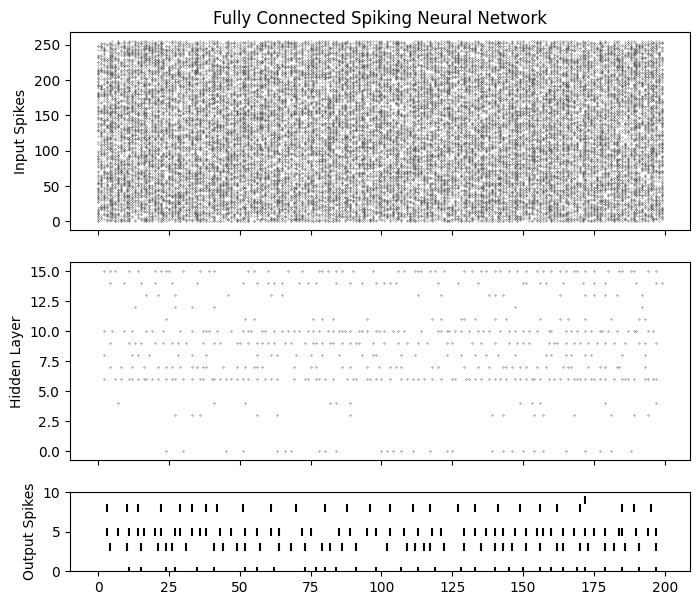

In [56]:
spk1_rec, mem1_rec, spk2_rec, mem2_rec = feedforward_nn.forward(train_spikes[0])

plot_snn_spikes(train_spikes[0], spk1_rec, spk2_rec, "Fully Connected Spiking Neural Network")

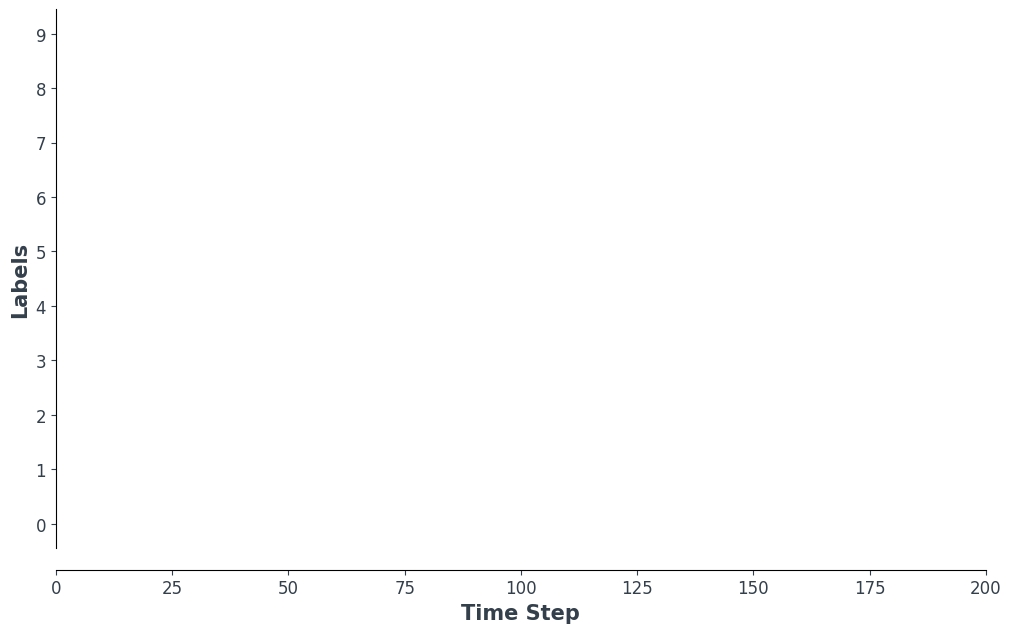

In [57]:
from IPython.display import HTML

fig, ax = plt.subplots(facecolor='w', figsize=(12, 7))
labels=['0', '1', '2', '3', '4', '5', '6', '7', '8','9']
spk2_rec = spk2_rec.squeeze(1).detach().cpu()

# plt.rcParams['animation.ffmpeg_path'] = 'C:\\path\\to\\your\\ffmpeg.exe'

#  Plot spike count histogram
anim = splt.spike_count(spk2_rec, fig, ax, labels=labels, animate=True)
HTML(anim.to_html5_video())
# anim.save("spike_bar.mp4")